# Task 2: Data Pipeline & Preprocessing

**Mục tiêu:**
- Làm sạch văn bản (Text Cleaning Pipeline)
- Khởi tạo Tokenizer từ Hugging Face (`microsoft/deberta-v3-base`)
- Phân tích phân phối Token Length
- Stratified K-Fold Split
- Xây dựng custom `Dataset` và `DataLoader` với PyTorch
- Kiểm tra pipeline end-to-end

## 0. Import Libraries & Cấu hình

In [1]:
import os
import re
import gc
import warnings
from pathlib import Path
from typing import Optional, List, Dict

import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold, train_test_split

import torch
from torch.utils.data import Dataset, DataLoader

from transformers import AutoTokenizer
from transformers import logging as hf_logging

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
hf_logging.set_verbosity_error()
plt.style.use('seaborn-v0_8-darkgrid')

ROOT      = Path('..').resolve()
DATA_DIR  = ROOT / 'data'
SAVE_DIR  = ROOT / 'outputs' / 'pipeline'
SAVE_DIR.mkdir(parents=True, exist_ok=True)

# Cấu hình pipeline 
class CFG:
    model_name  : str  = 'microsoft/deberta-v3-base'
    max_length  : int  = 512
    batch_size  : int  = 16
    num_workers : int  = 0      
    n_folds     : int  = 5
    val_fold    : int  = 0
    test_size   : float = 0.10
    seed        : int  = 42
    label_col   : str  = 'label'
    text_col    : str  = 'text'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def seed_everything(seed: int = 42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

seed_everything(CFG.seed)

print(f'Device      : {DEVICE}')
if torch.cuda.is_available():
    print(f'     : {torch.cuda.get_device_name(0)}')
print(f'     : {CFG.model_name}')
print(f'Max length  : {CFG.max_length}')
print(f'Batch size  : {CFG.batch_size}')
print(f'     : {ROOT}')
print(f'r    : {DATA_DIR}')

Device      : cuda
     : NVIDIA GeForce RTX 2050
     : microsoft/deberta-v3-base
Max length  : 512
Batch size  : 16
     : D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM
r    : D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\data


## 1. Load Dữ liệu

In [2]:
pkl_path = DATA_DIR / 'train_with_features.pkl'
csv_path = DATA_DIR / 'train_v2_drcat_02.csv'

def load_training_data(pkl_path: Path, csv_path: Path) -> pd.DataFrame:
    if pkl_path.exists():
        try:
            df = pd.read_pickle(pkl_path)
            print(f'Loaded from pickle (Task 1): shape={df.shape}')
            return df
        except (ModuleNotFoundError, ImportError, AttributeError, ValueError, TypeError) as exc:
            print(f'WARNING: cannot read {pkl_path.name}: {type(exc).__name__}: {exc}')
            print(f'Fallback to raw CSV: {csv_path.name}')

    if not csv_path.exists():
        raise FileNotFoundError(f'Cannot find {pkl_path} or {csv_path}')

    df = pd.read_csv(csv_path)
    print(f'Loaded from raw CSV: shape={df.shape}')
    return df

df = load_training_data(pkl_path, csv_path)

print(f'Columns: {df.columns.tolist()}')
print(f'\nPhan phoi nhan:')
print(df[CFG.label_col].value_counts().rename({0: 'Human (0)', 1: 'AI (1)'}).to_string())
df.head(3)

Loaded from pickle (Task 1): shape=(44868, 16)
Columns: ['text', 'label', 'prompt_name', 'source', 'RDizzl3_seven', 'word_count', 'char_count', 'sent_count', 'avg_word_len', 'unique_words', 'lexical_diversity', 'punct_count', 'digit_count', 'upper_ratio', 'words_per_sent', 'length_cat']

Phan phoi nhan:
label
Human (0)    27371
AI (1)       17497


,text,label,prompt_name,source,RDizzl3_seven,word_count,char_count,sent_count,avg_word_len,unique_words,lexical_diversity,punct_count,digit_count,upper_ratio,words_per_sent,length_cat
0,Phones\n\nModern humans today are always on th...,0,Phones and driving,persuade_corpus,False,379,2029,30,4.332454,212,0.559367,46,1,0.020207,12.633333,Dài (300-599)
1,This essay will explain if drivers should or s...,0,Phones and driving,persuade_corpus,False,366,2141,21,4.650273,183,0.500000,49,0,0.009341,17.428571,Dài (300-599)
2,Driving while the use of cellular devices\n\nT...,0,Phones and driving,persuade_corpus,False,178,1044,8,4.842697,112,0.629213,15,0,0.007663,22.250000,Trung bình (100-299)


## 2. Text Cleaning Pipeline

> **Triết lý làm sạch cho LLM Detection:**
> Không nên làm sạch quá mức (xóa stopwords, stemming) vì Transformer đã học đầy đủ ngữ cảnh.
> Chỉ chuẩn hóa các thành phần gây nhiễu kỹ thuật: unicode artifacts, whitespace dư thừa, URL, email.

In [3]:
class TextCleaner:
    """
    Pipeline làm sạch văn bản nhẹ (light cleaning) dành cho LLM Detection.

    Chiến lược: Giữ nguyên ngữ nghĩa, chỉ xử lý nhiễu kỹ thuật.
    - Chuẩn hóa unicode artifacts (smart quotes, em-dash, ellipsis...)
    - Thay thế URL / email bằng token đặc biệt
    - Chuẩn hóa whitespace (nhiều khoảng trắng → 1, nhiều newline → 2)
    """

    # Ánh xạ unicode artifacts → ký tự ASCII tương đương
    _UNICODE_MAP: Dict[str, str] = {
        '\u2018': "'",  '\u2019': "'",   # smart apostrophes
        '\u201c': '"',  '\u201d': '"',   # smart double quotes
        '\u2013': '-',  '\u2014': '-',   # en-dash, em-dash
        '\u2026': '...',                  # ellipsis
        '\u00a0': ' ',                    # non-breaking space
        '\u200b': '',   '\u200c': '',     # zero-width spaces
        '\u200d': '',   '\ufeff': '',     # zero-width joiner, BOM
    }

    def __init__(
        self,
        remove_urls             : bool = True,
        remove_emails           : bool = True,
        normalize_unicode       : bool = True,
        normalize_whitespace    : bool = True,
    ):
        self.remove_urls          = remove_urls
        self.remove_emails        = remove_emails
        self.normalize_unicode    = normalize_unicode
        self.normalize_whitespace = normalize_whitespace

        # Compile regex patterns một lần (tối ưu tốc độ)
        self._url_re   = re.compile(
            r'https?://[^\s<>"{}|\\^`\[\]]+', re.IGNORECASE)
        self._email_re = re.compile(
            r'[a-zA-Z0-9._%+\-]+@[a-zA-Z0-9.\-]+\.[a-zA-Z]{2,}')
        self._ws_re    = re.compile(r'[ \t]+')
        self._nl_re    = re.compile(r'\n{3,}')

    def clean(self, text: str) -> str:
        """Làm sạch một chuỗi văn bản."""
        if not isinstance(text, str) or not text.strip():
            return ''

        # Bước 1: Chuẩn hóa unicode
        if self.normalize_unicode:
            for src, tgt in self._UNICODE_MAP.items():
                text = text.replace(src, tgt)

        # Bước 2: Xóa URLs (thay bằng token đặc biệt)
        if self.remove_urls:
            text = self._url_re.sub('[URL]', text)

        # Bước 3: Xóa emails
        if self.remove_emails:
            text = self._email_re.sub('[EMAIL]', text)

        # Bước 4: Chuẩn hóa whitespace
        if self.normalize_whitespace:
            text = self._ws_re.sub(' ', text)    # nhiều space/tab → 1 space
            text = self._nl_re.sub('\n\n', text) # 3+ newlines → 2 newlines

        return text.strip()

    def clean_batch(
        self,
        texts  : List[str],
        verbose: bool = True
    ) -> List[str]:
        """Làm sạch batch văn bản với thanh tiến trình."""
        if verbose:
            return [self.clean(t) for t in tqdm(texts, desc='Cleaning texts')]
        return [self.clean(t) for t in texts]


# Test TextCleaner 
cleaner = TextCleaner()

test_cases = [
    'Visit https://example.com or mail foo@bar.com for info.',
    'She said \u201cHello!\u201d \u2014 It\u2019s great\u2026',
    'Paragraph 1.\n\n\n\n\nParagraph 2.',
    '   Lots   of   spaces   ',
]
print('TextCleaner:')
print('-' * 60)
for raw in test_cases:
    cleaned = cleaner.clean(raw)
    print(f'  IN : {repr(raw[:70])}')
    print(f'  OUT: {repr(cleaned[:70])}')
    print()

TextCleaner:
------------------------------------------------------------
  IN : 'Visit https://example.com or mail foo@bar.com for info.'
  OUT: 'Visit [URL] or mail [EMAIL] for info.'

  IN : 'She said “Hello!” — It’s great…'
  OUT: 'She said "Hello!" - It\'s great...'

  IN : 'Paragraph 1.\n\n\n\n\nParagraph 2.'
  OUT: 'Paragraph 1.\n\nParagraph 2.'

  IN : '   Lots   of   spaces   '
  OUT: 'Lots of spaces'



In [4]:
# Áp dụng TextCleaner lên toàn bộ dataset 
print(f'Đang làm sạch {len(df):,} văn bản...')
df['text_clean'] = cleaner.clean_batch(df[CFG.text_col].tolist(), verbose=True)

# Kiểm tra mẫu rỗng sau khi cleaning
n_empty = (df['text_clean'].str.strip() == '').sum()
print(f'\nrỗng sau cleaning : {n_empty}')

if n_empty > 0:
    df = df[df['text_clean'].str.strip() != ''].reset_index(drop=True)
    print(f'Đã loại {n_empty} mẫu rỗng. Shape mới: {df.shape}')

# So sánh trước/sau
print(f'\n Trước cleaning ({len(df[CFG.text_col].iloc[0].split())} từ):')
print(df[CFG.text_col].iloc[0][:200])
print(f'\n Sau cleaning ({len(df["text_clean"].iloc[0].split())} từ):')
print(df['text_clean'].iloc[0][:200])
print('\ncleaning hoàn tất!')

Đang làm sạch 44,868 văn bản...


Cleaning texts:   0%|          | 0/44868 [00:00<?, ?it/s]


rỗng sau cleaning : 0

 Trước cleaning (379 từ):
Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop .All they do is text back and forward and just have group Chats on social media. T

 Sau cleaning (379 từ):
Phones

Modern humans today are always on their phone. They are always on their phone more than 5 hours a day no stop .All they do is text back and forward and just have group Chats on social media. T

cleaning hoàn tất!


## 3. Stratified K-Fold Split

In [5]:
def add_train_val_test_split_and_folds(
    df: pd.DataFrame,
    label_col: str = 'label',
    n_folds: int = 5,
    test_size: float = 0.10,
    seed: int = 42,
) -> pd.DataFrame:
    """Create a held-out test split, then StratifiedKFold only on train_val rows."""
    df = df.copy().reset_index(drop=True)
    df['split'] = 'train_val'
    df['fold'] = -1

    train_val_idx, test_idx = train_test_split(
        df.index,
        test_size=test_size,
        random_state=seed,
        stratify=df[label_col],
    )
    df.loc[test_idx, 'split'] = 'test'

    train_val_idx = np.array(train_val_idx)
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=seed)
    for fold_id, (_, val_pos) in enumerate(skf.split(df.loc[train_val_idx], df.loc[train_val_idx, label_col])):
        df.loc[train_val_idx[val_pos], 'fold'] = fold_id

    return df


def print_split_summary(df: pd.DataFrame, label_col: str = 'label') -> None:
    rows = []
    for name, sub in [
        ('train_val', df[df['split'] == 'train_val']),
        ('test', df[df['split'] == 'test']),
    ]:
        total = len(sub)
        human = int((sub[label_col] == 0).sum())
        ai = int((sub[label_col] == 1).sum())
        rows.append({
            'split': name,
            'total': total,
            'human': human,
            'ai': ai,
            'human_pct': human / total * 100 if total else 0,
            'ai_pct': ai / total * 100 if total else 0,
        })
    display(pd.DataFrame(rows))


def print_fold_summary(df: pd.DataFrame, label_col: str = 'label', n_folds: int = 5) -> None:
    fold_rows = []
    pool = df[df['split'] == 'train_val']
    for fid in range(n_folds):
        sub = pool[pool['fold'] == fid]
        total = len(sub)
        human = int((sub[label_col] == 0).sum())
        ai = int((sub[label_col] == 1).sum())
        fold_rows.append({
            'fold': fid,
            'total': total,
            'human': human,
            'ai': ai,
            'human_pct': human / total * 100 if total else 0,
            'ai_pct': ai / total * 100 if total else 0,
        })
    display(pd.DataFrame(fold_rows))


# Recreate split/fold when split is missing. Existing split is kept for reproducibility.
if 'split' not in df.columns:
    df = add_train_val_test_split_and_folds(
        df,
        label_col=CFG.label_col,
        n_folds=CFG.n_folds,
        test_size=CFG.test_size,
        seed=CFG.seed,
    )
    print(f'Created stratified hold-out test split: {CFG.test_size:.0%}')
else:
    print('Column split already exists - keeping existing train_val/test split.')
    if 'fold' not in df.columns:
        df['fold'] = -1

# Ensure train_val rows have folds. Test rows always keep fold=-1.
train_val_mask = df['split'].eq('train_val')
if (df.loc[train_val_mask, 'fold'] < 0).any():
    print('Recreating folds for train_val rows.')
    df.loc[:, 'fold'] = -1
    train_val_idx = df.index[train_val_mask].to_numpy()
    skf = StratifiedKFold(n_splits=CFG.n_folds, shuffle=True, random_state=CFG.seed)
    for fold_id, (_, val_pos) in enumerate(skf.split(df.loc[train_val_idx], df.loc[train_val_idx, CFG.label_col])):
        df.loc[train_val_idx[val_pos], 'fold'] = fold_id

df.loc[df['split'].eq('test'), 'fold'] = -1

train_val_df = df[df['split'] == 'train_val'].reset_index(drop=True)
train_df = train_val_df[train_val_df['fold'] != CFG.val_fold].reset_index(drop=True)
valid_df = train_val_df[train_val_df['fold'] == CFG.val_fold].reset_index(drop=True)
test_df = df[df['split'] == 'test'].reset_index(drop=True)

print_split_summary(df, CFG.label_col)
print_fold_summary(df, CFG.label_col, CFG.n_folds)

print(f'\nTrain : {len(train_df):,} samples')
print(f'Valid : {len(valid_df):,} samples')
print(f'Test  : {len(test_df):,} samples')


Created stratified hold-out test split: 10%


,split,total,human,ai,human_pct,ai_pct
0,train_val,40381,24634,15747,61.003937,38.996063
1,test,4487,2737,1750,60.998440,39.001560


,fold,total,human,ai,human_pct,ai_pct
0,0,8077,4927,3150,61.000371,38.999629
1,1,8076,4926,3150,60.995542,39.004458
2,2,8076,4927,3149,61.007925,38.992075
3,3,8076,4927,3149,61.007925,38.992075
4,4,8076,4927,3149,61.007925,38.992075



Train : 32,304 samples
Valid : 8,077 samples
Test  : 4,487 samples


## 4. Khởi tạo Tokenizer

In [6]:
print(f'Đang tải tokenizer: {CFG.model_name} ...')
tokenizer = AutoTokenizer.from_pretrained(CFG.model_name)
print(f'izer sẵn sàng!')
print(f'  Vocab size       : {tokenizer.vocab_size:,}')
print(f'  Max model length : {tokenizer.model_max_length}')
print(f'  PAD token        : {repr(tokenizer.pad_token)} (id={tokenizer.pad_token_id})')
print(f'  CLS token        : {repr(tokenizer.cls_token)} (id={tokenizer.cls_token_id})')
print(f'  SEP token        : {repr(tokenizer.sep_token)} (id={tokenizer.sep_token_id})')

# Demo tokenization
demo_text = train_df['text_clean'].iloc[0]
encoded   = tokenizer(
    demo_text,
    max_length    = CFG.max_length,
    truncation    = True,
    padding       = 'max_length',
    return_tensors= 'pt',
)

print(f'\n[DEMO] Văn bản mẫu ({len(demo_text.split())} từ):')
print(f'  input_ids shape       : {encoded["input_ids"].shape}')
print(f'  attention_mask shape  : {encoded["attention_mask"].shape}')
n_real_tokens = encoded['attention_mask'].sum().item()
n_pad_tokens  = CFG.max_length - n_real_tokens
print(f'  Real tokens           : {n_real_tokens}')
print(f'  Padding tokens        : {n_pad_tokens}')
print(f'  Decoded (10 đầu)      : {tokenizer.decode(encoded["input_ids"][0, :10])}')

Đang tải tokenizer: microsoft/deberta-v3-base ...


izer sẵn sàng!
  Vocab size       : 128,000
  Max model length : 1000000000000000019884624838656
  PAD token        : '[PAD]' (id=0)
  CLS token        : '[CLS]' (id=1)
  SEP token        : '[SEP]' (id=2)

[DEMO] Văn bản mẫu (379 từ):
  input_ids shape       : torch.Size([1, 512])
  attention_mask shape  : torch.Size([1, 512])
  Real tokens           : 442
  Padding tokens        : 70
  Decoded (10 đầu)      : [CLS] Phones Modern humans today are always on their phone


## 5. Phân tích Token Length Distribution
Phân tích để chọn `max_length` phù hợp — quá nhỏ làm mất thông tin, quá lớn lãng phí compute.

In [7]:
# Sample ngẫu nhiên để tính token length nhanh
SAMPLE_N = min(3000, len(df))
sample    = df.sample(SAMPLE_N, random_state=CFG.seed)

print(f'ing {SAMPLE_N} mẫu để thống kê token length...')
token_lengths = []
for text in tqdm(sample['text_clean'].tolist(), ncols=80):
    ids = tokenizer.encode(text, truncation=False, add_special_tokens=True)
    token_lengths.append(len(ids))

tok_arr   = np.array(token_lengths)
tok_labels= sample[CFG.label_col].values

print(f'\n[THỐNG KÊ TOKEN LENGTH]')
print(f'  Mean   : {tok_arr.mean():.1f}')
print(f'  Std    : {tok_arr.std():.1f}')
print(f'  Min    : {tok_arr.min()}')
for p in [50, 75, 90, 95, 99]:
    print(f'  P{p:<3}   : {np.percentile(tok_arr, p):.0f}')
print(f'  Max    : {tok_arr.max()}')
pct_trunc = (tok_arr > CFG.max_length).mean() * 100
print(f'\n  Bị truncate tại max_length={CFG.max_length} : {pct_trunc:.1f}% mẫu')

ing 3000 mẫu để thống kê token length...


  0%|                                                  | 0/3000 [00:00<?, ?it/s]


[THỐNG KÊ TOKEN LENGTH]
  Mean   : 447.3
  Std    : 189.5
  Min    : 50
  P50    : 418
  P75    : 525
  P90    : 695
  P95    : 812
  P99    : 1077
  Max    : 1899

  Bị truncate tại max_length=512 : 26.6% mẫu


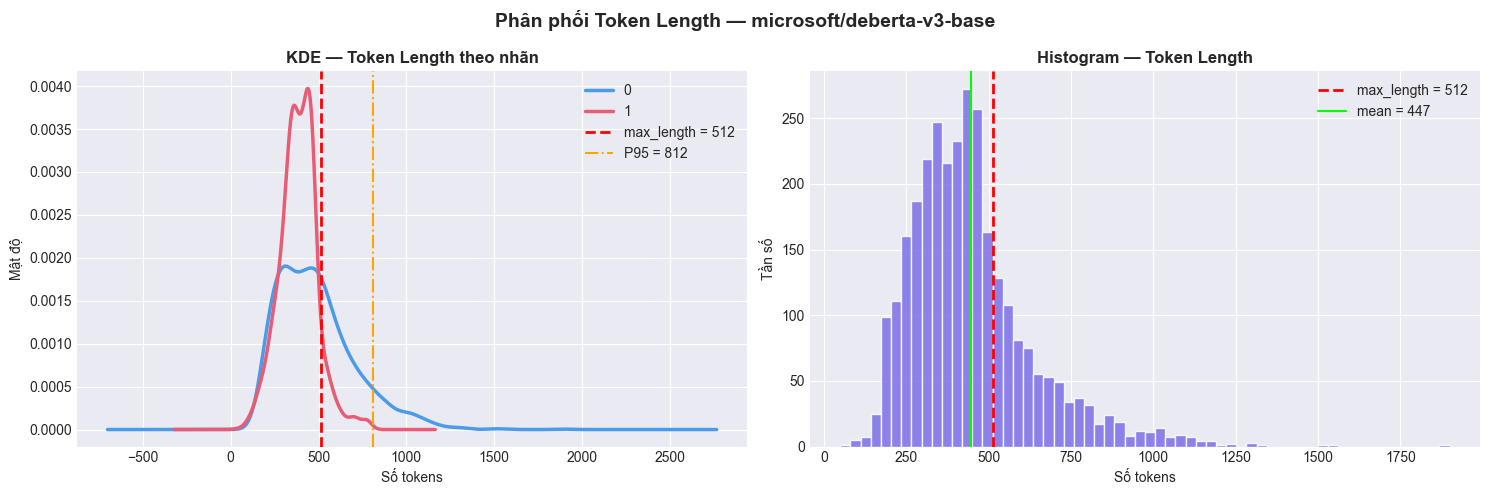

Saved: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\outputs\pipeline\token_length_distribution.png


In [8]:
# Visualize token length 
COLORS = ['#4C9BE8', '#E85D75']
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(f'Phân phối Token Length — {CFG.model_name}',
             fontsize=14, fontweight='bold')

# KDE theo nhãn
df_tok = pd.DataFrame({'token_length': tok_arr, 'label': tok_labels})
for lid, (name, color) in enumerate([(0, 'Human'), (1, 'AI')]):
    data = df_tok[df_tok['label'] == lid]['token_length']
    data.plot.kde(ax=axes[0], color=COLORS[lid], linewidth=2.5, label=name)

axes[0].axvline(CFG.max_length, color='red', linestyle='--', lw=2,
                label=f'max_length = {CFG.max_length}')
axes[0].axvline(np.percentile(tok_arr, 95), color='orange', linestyle='-.',
                lw=1.5, label=f'P95 = {np.percentile(tok_arr,95):.0f}')
axes[0].set_xlabel('Số tokens'); axes[0].set_ylabel('Mật độ')
axes[0].set_title('KDE — Token Length theo nhãn', fontweight='bold')
axes[0].legend(fontsize=10); sns.despine(ax=axes[0])

# Histogram
axes[1].hist(tok_arr, bins=60, color='#7C6FE8', alpha=0.85, edgecolor='white')
axes[1].axvline(CFG.max_length, color='red', linestyle='--', lw=2,
                label=f'max_length = {CFG.max_length}')
axes[1].axvline(tok_arr.mean(), color='lime', linestyle='-', lw=1.5,
                label=f'mean = {tok_arr.mean():.0f}')
axes[1].set_xlabel('Số tokens'); axes[1].set_ylabel('Tần số')
axes[1].set_title('Histogram — Token Length', fontweight='bold')
axes[1].legend(fontsize=10); sns.despine(ax=axes[1])

plt.tight_layout()
plt.savefig(SAVE_DIR / 'token_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {SAVE_DIR / "token_length_distribution.png"}')

## 6. Custom PyTorch Dataset

In [9]:
class AITextDataset(Dataset):
    """
    Custom PyTorch Dataset cho bài toán phân loại Human/AI.

    Args:
        texts     : List[str] — danh sách văn bản đã làm sạch
        tokenizer : HuggingFace tokenizer (DeBERTa)
        max_length: int — độ dài token tối đa
        labels    : Optional[List[int]] — nhãn 0/1; None với test set

    Returns (mỗi __getitem__):
        input_ids      : LongTensor [max_length]
        attention_mask : LongTensor [max_length]
        token_type_ids : LongTensor [max_length] (nếu model hỗ trợ)
        labels         : LongTensor [] (nếu không phải test set)
    """

    def __init__(
        self,
        texts     : List[str],
        tokenizer ,
        max_length: int,
        labels    : Optional[List[int]] = None,
    ):
        assert len(texts) > 0, 'Dataset rỗng!'
        if labels is not None:
            assert len(texts) == len(labels), 'texts và labels phải có cùng độ dài!'

        self.texts      = texts
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.labels     = labels
        self.is_test    = (labels is None)

    def __len__(self) -> int:
        return len(self.texts)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        text = self.texts[idx]

        encoding = self.tokenizer(
            text,
            max_length           = self.max_length,
            padding              = 'max_length',
            truncation           = True,
            return_tensors       = 'pt',
            return_attention_mask= True,
        )

        item: Dict[str, torch.Tensor] = {
            'input_ids'     : encoding['input_ids'].squeeze(0),      
            'attention_mask': encoding['attention_mask'].squeeze(0),  
        }

        # Token type ids (không phải tất cả model đều trả về)
        if 'token_type_ids' in encoding:
            item['token_type_ids'] = encoding['token_type_ids'].squeeze(0)

        # Label
        if not self.is_test:
            item['labels'] = torch.tensor(
                self.labels[idx], dtype=torch.long
            )

        return item

    def __repr__(self) -> str:
        return (f'AITextDataset('
                f'n={len(self)}, '
                f'max_length={self.max_length}, '
                f'is_test={self.is_test})')


# Khởi tạo train/valid datasets
train_dataset = AITextDataset(
    texts      = train_df['text_clean'].tolist(),
    tokenizer  = tokenizer,
    max_length = CFG.max_length,
    labels     = train_df[CFG.label_col].tolist(),
)
valid_dataset = AITextDataset(
    texts      = valid_df['text_clean'].tolist(),
    tokenizer  = tokenizer,
    max_length = CFG.max_length,
    labels     = valid_df[CFG.label_col].tolist(),
)

print(f'Train dataset: {len(train_dataset)} samples')
print(f'Valid dataset: {len(valid_dataset)} samples')

# Kiểm tra 1 sample 
sample = train_dataset[0]
print(f'\n Keys        : {list(sample.keys())}')
print(f' input_ids   : shape={sample["input_ids"].shape}, dtype={sample["input_ids"].dtype}')
print(f' attn_mask   : shape={sample["attention_mask"].shape}')
print(f' label       : {sample["labels"].item()} → {"Human" if sample["labels"].item()==0 else "AI"}')
print(f' Real tokens : {sample["attention_mask"].sum().item()}')
print(f' Pad tokens  : {(sample["attention_mask"]==0).sum().item()}')

Train dataset: 32304 samples
Valid dataset: 8077 samples

 Keys        : ['input_ids', 'attention_mask', 'token_type_ids', 'labels']
 input_ids   : shape=torch.Size([512]), dtype=torch.int64
 attn_mask   : shape=torch.Size([512])
 label       : 0 → Human
 Real tokens : 442
 Pad tokens  : 70


## 7. DataLoader

In [10]:
def create_dataloader(
    dataset    : Dataset,
    batch_size : int,
    shuffle    : bool = False,
    num_workers: int  = 0,
    pin_memory : bool = True,
) -> DataLoader:
    """
    Factory function tạo DataLoader với cấu hình tối ưu.

    Tips:
      - shuffle=True chỉ dùng cho train loader
      - pin_memory=True tăng tốc CPU→GPU transfer (chỉ khi dùng CUDA)
      - num_workers=0 trên Windows (tránh deadlock với multiprocessing)
    """
    return DataLoader(
        dataset,
        batch_size  = batch_size,
        shuffle     = shuffle,
        num_workers = num_workers,
        pin_memory  = pin_memory and torch.cuda.is_available(),
        drop_last   = False,
    )


# Khởi tạo DataLoaders 
train_loader = create_dataloader(
    train_dataset, CFG.batch_size, shuffle=True,
    num_workers=CFG.num_workers
)
valid_loader = create_dataloader(
    valid_dataset, CFG.batch_size, shuffle=False,
    num_workers=CFG.num_workers
)

print(f'ataLoader : {len(train_loader):,} batches '
      f'(batch_size={CFG.batch_size})')
print(f'Valid DataLoader : {len(valid_loader):,} batches')

# Inspect 1 batch 
batch = next(iter(train_loader))
print(f'\n[BATCH] Keys          : {list(batch.keys())}')
print(f'[BATCH] input_ids     : {batch["input_ids"].shape}')    # [B, max_len]
print(f'[BATCH] attention_mask: {batch["attention_mask"].shape}')
print(f'[BATCH] labels        : {batch["labels"].tolist()}')
print(f'[BATCH] Label counts  : Human={( batch["labels"]==0).sum().item()} | AI={(batch["labels"]==1).sum().item()}')

# Ước tính memory mỗi batch
bytes_per_batch = (
    batch['input_ids'].element_size() * batch['input_ids'].nelement() +
    batch['attention_mask'].element_size() * batch['attention_mask'].nelement()
)
print(f'[MEMORY] Input tensors mỗi batch: ~{bytes_per_batch / 1024:.1f} KB')

ataLoader : 2,019 batches (batch_size=16)
Valid DataLoader : 505 batches

[BATCH] Keys          : ['input_ids', 'attention_mask', 'token_type_ids', 'labels']
[BATCH] input_ids     : torch.Size([16, 512])
[BATCH] attention_mask: torch.Size([16, 512])
[BATCH] labels        : [0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0]
[BATCH] Label counts  : Human=7 | AI=9
[MEMORY] Input tensors mỗi batch: ~128.0 KB


## 8. Kiểm tra Pipeline End-to-End

In [11]:
def validate_pipeline(
    loader   : DataLoader,
    device   : torch.device,
    n_batches: int = 3,
    name     : str = 'Loader',
) -> None:
    """
    Chạy thử pipeline để đảm bảo:
    - Tensor shapes đúng
    - Không có giá trị âm trong input_ids
    - Attention mask chỉ chứa 0 hoặc 1
    - Labels hợp lệ (0 hoặc 1)
    - GPU transfer hoạt động
    """
    print(f'Kiểm tra {name} ({n_batches} batches đầu)...')
    print(f'  {"Batch":<6} {"IDs shape":<20} {"Real tokens":>12} {"Pad tokens":>12} {"Labels"}')
    print('  ' + '-' * 75)

    for i, batch in enumerate(loader):
        if i >= n_batches:
            break

        # Move to device
        input_ids  = batch['input_ids'].to(device)
        attn_mask  = batch['attention_mask'].to(device)
        labels     = batch['labels'].to(device)

        # Kiểm tra tính hợp lệ
        assert input_ids.min() >= 0,     f'input_ids có giá trị âm!'
        assert attn_mask.max() <= 1,     f'attention_mask > 1!'
        assert attn_mask.min() >= 0,     f'attention_mask < 0!'
        assert labels.max() <= 1,        f'labels > 1!'
        assert labels.min() >= 0,        f'labels < 0!'
        assert input_ids.device.type == device.type, f'Tensor không ở đúng device!'

        n_real = attn_mask.sum().item()
        n_pad  = (attn_mask == 0).sum().item()
        print(f'  {i:<6} {str(tuple(input_ids.shape)):<20} '
              f'{n_real:>12,} {n_pad:>12,} {labels.cpu().tolist()[:5]}...')

    print(f'{name} hợp lệ!\n')


validate_pipeline(train_loader, DEVICE, n_batches=3, name='Train Loader')
validate_pipeline(valid_loader, DEVICE, n_batches=2, name='Valid Loader')

Kiểm tra Train Loader (3 batches đầu)...
  Batch  IDs shape             Real tokens   Pad tokens Labels
  ---------------------------------------------------------------------------
  0      (16, 512)                   5,296        2,896 [0, 0, 0, 0, 0]...
  1      (16, 512)                   6,697        1,495 [0, 0, 0, 1, 1]...
  2      (16, 512)                   6,330        1,862 [1, 0, 1, 1, 0]...
Train Loader hợp lệ!

Kiểm tra Valid Loader (2 batches đầu)...
  Batch  IDs shape             Real tokens   Pad tokens Labels
  ---------------------------------------------------------------------------
  0      (16, 512)                   7,320          872 [0, 0, 0, 0, 0]...
  1      (16, 512)                   6,944        1,248 [0, 0, 0, 0, 0]...
Valid Loader hợp lệ!



## 9. Lưu dữ liệu đã xử lý

In [12]:
# Lưu cleaned data cho Task 3, 4 
save_cols = ['text_clean', CFG.label_col, 'split', 'fold']
clean_path = DATA_DIR / 'train_clean.pkl'

df[save_cols].to_pickle(clean_path)
print(f'Lưu cleaned data: {clean_path}')
print(f'   Shape   : {df[save_cols].shape}')
print(f'   Columns : {save_cols}')

# Tóm tắt thông tin pipeline 
print()
print('=' * 60)
print('TỔNG KẾT PIPELINE — Task 2')
print('=' * 60)
summary = [
    ('Tokenizer',            CFG.model_name),
    ('Max token length',     str(CFG.max_length)),
    ('Tổng mẫu',             f'{len(df):,}'),
    ('Train samples',        f'{len(train_df):,}'),
    ('Valid samples',        f'{len(valid_df):,}'),
    ('Test samples',         f'{len(test_df):,}'),
    ('Train batches',        f'{len(train_loader):,}'),
    ('Valid batches',        f'{len(valid_loader):,}'),
    ('Batch size',           str(CFG.batch_size)),
    ('% bị truncate',        f'{(tok_arr > CFG.max_length).mean()*100:.1f}%'),
    ('Cleaned data path',    str(clean_path)),
]
for key, val in summary:
    print(f'  {key:<25} : {val}')
print('=' * 60)
print('\nTask 2 — Data Pipeline hoàn tất!')
print('→ Tiếp tục với Task 3: task3_deberta_training.ipynb')

Lưu cleaned data: D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\data\train_clean.pkl
   Shape   : (44868, 4)
   Columns : ['text_clean', 'label', 'split', 'fold']

TỔNG KẾT PIPELINE — Task 2
  Tokenizer                 : microsoft/deberta-v3-base
  Max token length          : 512
  Tổng mẫu                  : 44,868
  Train samples             : 32,304
  Valid samples             : 8,077
  Test samples              : 4,487
  Train batches             : 2,019
  Valid batches             : 505
  Batch size                : 16
  % bị truncate             : 26.6%
  Cleaned data path         : D:\HuynhHan\Hoc_thong_ke\Detect-AI-Generated-Text-Using-LLM\data\train_clean.pkl

Task 2 — Data Pipeline hoàn tất!
→ Tiếp tục với Task 3: task3_deberta_training.ipynb
